# Extracción de Personalidad a partir de Preferencias de Género

En este notebook extraemos los **rasgos de personalidad Big Five** de cada usuario basándonos en sus preferencias de géneros cinematográficos.

El modelo **Big Five** (también conocido como OCEAN) define la personalidad en 5 dimensiones:

| Rasgo | Descripción |
|---|---|
| **Openness** (Apertura) | Curiosidad intelectual, creatividad, apertura a nuevas experiencias |
| **Conscientiousness** (Responsabilidad) | Organización, disciplina, orientación a metas |
| **Extraversion** (Extraversión) | Sociabilidad, energía, emociones positivas |
| **Agreeableness** (Amabilidad) | Cooperación, empatía, consideración hacia los demás |
| **Neuroticism** (Neuroticismo) | Tendencia a la ansiedad, inestabilidad emocional |

Utilizaremos la **matriz de personalidad por género** propuesta en la literatura (Nave et al., 2017) para derivar los rasgos de personalidad de cada usuario a partir de sus calificaciones promedio por género cinematográfico.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import ast

import warnings
warnings.filterwarnings('ignore')

## Carga del Dataset de Ratings

Cargamos directamente el dataset filtrado (`ratings_final.parquet`). Dado que todos los 10,000 usuarios ya tienen entre 50 y 199 ratings sobre las 5,000 películas seleccionadas, este dataset nos garantiza cobertura completa de personalidad para todos los usuarios.

In [2]:
# Use the filtered ratings directly (all 10,000 users, curated movies only)
rdf = pd.read_parquet('../data/processed/ratings_final.parquet')
rdf.head()

,user_id,movie_id,rating,timestamp
0,31,25,5.0,1673768714
1,31,23,4.0,1673768620
2,31,70,4.5,1673768766
3,31,176,5.0,1673768427
4,31,287,0.5,1673843631


In [3]:
print(f'We have {rdf.shape[0]:,} ratings from {len(rdf["user_id"].unique()):,} users')

We have 1,014,059 ratings from 10,000 users


## Carga del Dataset de Películas

Cargamos el dataset de películas para extraer los géneros de cada una.

In [4]:
mdf = pd.read_csv('../data/processed/movies_final.csv')
mdf = mdf[['movie_id', 'title', 'genres']]
mdf.head()

,movie_id,title,genres
0,0,GoldenEye,"['Adventure', 'Action', 'Thriller']"
1,1,Heat,"['Crime', 'Drama', 'Action']"
2,2,Toy Story,"['Family', 'Comedy', 'Animation', 'Adventure']"
3,3,Jumanji,"['Adventure', 'Fantasy', 'Family']"
4,4,The American President,"['Drama', 'Romance']"


Parseamos la columna `genres` de string a lista de Python y eliminamos las películas sin género.

In [5]:
import ast
# Parse genres from string to list
mdf['genres'] = mdf['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
mdf['genres'] = mdf['genres'].apply(lambda x: np.nan if not x else x)
mdf.dropna(subset='genres', inplace=True)
mdf.head()

,movie_id,title,genres
0,0,GoldenEye,"[Adventure, Action, Thriller]"
1,1,Heat,"[Crime, Drama, Action]"
2,2,Toy Story,"[Family, Comedy, Animation, Adventure]"
3,3,Jumanji,"[Adventure, Fantasy, Family]"
4,4,The American President,"[Drama, Romance]"


In [6]:
print(f'We end up with {mdf.shape[0]:,} movies')

We end up with 5,000 movies


Para la extracción de personalidad, utilizamos únicamente los géneros que están representados en la matriz de personalidad del paper:

- Action (Acción)
- Adventure (Aventura)
- Animation (Animación)
- Comedy (Comedia)
- Drama
- Horror (Terror)
- Romance
- Science Fiction (Ciencia Ficción)
- War (Bélica)

Descartamos géneros como Thriller, Documentary o Fantasy que no aparecen en la matriz.

In [7]:
genres = {'Action', 'Adventure', 'Animation', 'Comedy', 'Drama', 'Horror', 'Romance', 'Science Fiction', 'War'}
def select_genres(x):
    new = [genre for genre in x if genre in genres]
    return new if new else np.nan

In [8]:
# Select only the genres we want. If a film does not have a genre, we set it null
mdf['genres'] = mdf['genres'].apply(lambda x: select_genres(x))
# Delete the movies that does not have the desires genres
mdf = mdf.dropna(subset='genres')
print(f'We have {mdf.shape[0]:,} movies that have at least one of the desired genres')

We have 4,672 movies that have at least one of the desired genres


### Unión de Ratings y Películas

Hacemos el join entre ratings y películas para obtener el género de cada calificación. Esto nos permitirá calcular la calificación promedio que cada usuario da a cada género.

In [9]:
# Merge the dataframes
df = mdf.merge(rdf, on='movie_id')
# All users already have 50-199 ratings, no need for additional filtering
# Select the relevant features
df = df[['user_id', 'genres', 'rating']]
df.head()

,user_id,genres,rating
0,215,"[Adventure, Action]",3.5
1,239,"[Adventure, Action]",3.0
2,298,"[Adventure, Action]",3.5
3,335,"[Adventure, Action]",4.0
4,516,"[Adventure, Action]",3.5


In [10]:
print(f'We have {df.shape[0]:,} ratings of {len(df["user_id"].unique()):,} users')

We have 978,030 ratings of 10,000 users


### Calificación Promedio por Género para Cada Usuario

In [11]:
# Expand the genres (1 per row)
df = df.explode('genres')
df.head(10)

,user_id,genres,rating
0,215,Adventure,3.5
0,215,Action,3.5
1,239,Adventure,3.0
1,239,Action,3.0
2,298,Adventure,3.5
2,298,Action,3.5
3,335,Adventure,4.0
3,335,Action,4.0
4,516,Adventure,3.5
4,516,Action,3.5


Calculamos la **proporción de películas vistas por género** para cada usuario. Esta información se usará como peso en el método de géneros ponderados.

In [12]:
genre_counts = df.groupby(['user_id', 'genres']).size().unstack(fill_value=0)
genre_counts.head()

genres,Action,Adventure,Animation,Comedy,Drama,Horror,Romance,Science Fiction,War
user_id,,,,,,,,,
31,14,19,15,23,27,4,7,11,1
65,11,4,0,4,30,1,8,2,6
75,29,24,8,7,16,4,0,16,4
81,31,46,14,17,12,11,1,16,1
110,21,23,18,21,41,4,5,16,7


In [13]:
# Get the proportion per genre
genre_proportions = genre_counts.div(genre_counts.sum(axis=1), axis=0)
genre_proportions.head()

genres,Action,Adventure,Animation,Comedy,Drama,Horror,Romance,Science Fiction,War
user_id,,,,,,,,,
31,0.115702,0.157025,0.123967,0.190083,0.223140,0.033058,0.057851,0.090909,0.008264
65,0.166667,0.060606,0.000000,0.060606,0.454545,0.015152,0.121212,0.030303,0.090909
75,0.268519,0.222222,0.074074,0.064815,0.148148,0.037037,0.000000,0.148148,0.037037
81,0.208054,0.308725,0.093960,0.114094,0.080537,0.073826,0.006711,0.107383,0.006711
110,0.134615,0.147436,0.115385,0.134615,0.262821,0.025641,0.032051,0.102564,0.044872


Calculamos la calificación promedio que cada usuario asignó a cada género. Las entradas con valor 0 corresponden a géneros que el usuario no ha calificado.

In [14]:
# Obtain the average
df = df.groupby(by=['user_id', 'genres']).aggregate('mean').reset_index()
df = df.pivot(index='user_id', columns='genres', values='rating').fillna(0)
df.head()

genres,Action,Adventure,Animation,Comedy,Drama,Horror,Romance,Science Fiction,War
user_id,,,,,,,,,
31,3.642857,3.578947,3.733333,4.260870,4.296296,4.000,3.571429,3.50000,5.000000
65,2.954545,2.750000,0.000000,2.500000,3.266667,1.500,3.250000,3.00000,3.250000
75,4.568966,3.958333,2.375000,2.642857,4.250000,4.250,0.000000,4.06250,5.000000
81,3.435484,3.467391,2.642857,3.058824,3.583333,2.500,2.000000,2.62500,4.000000
110,3.166667,3.282609,3.638889,3.452381,3.695122,3.125,3.600000,3.40625,3.571429


### Distribución de Calificaciones por Género

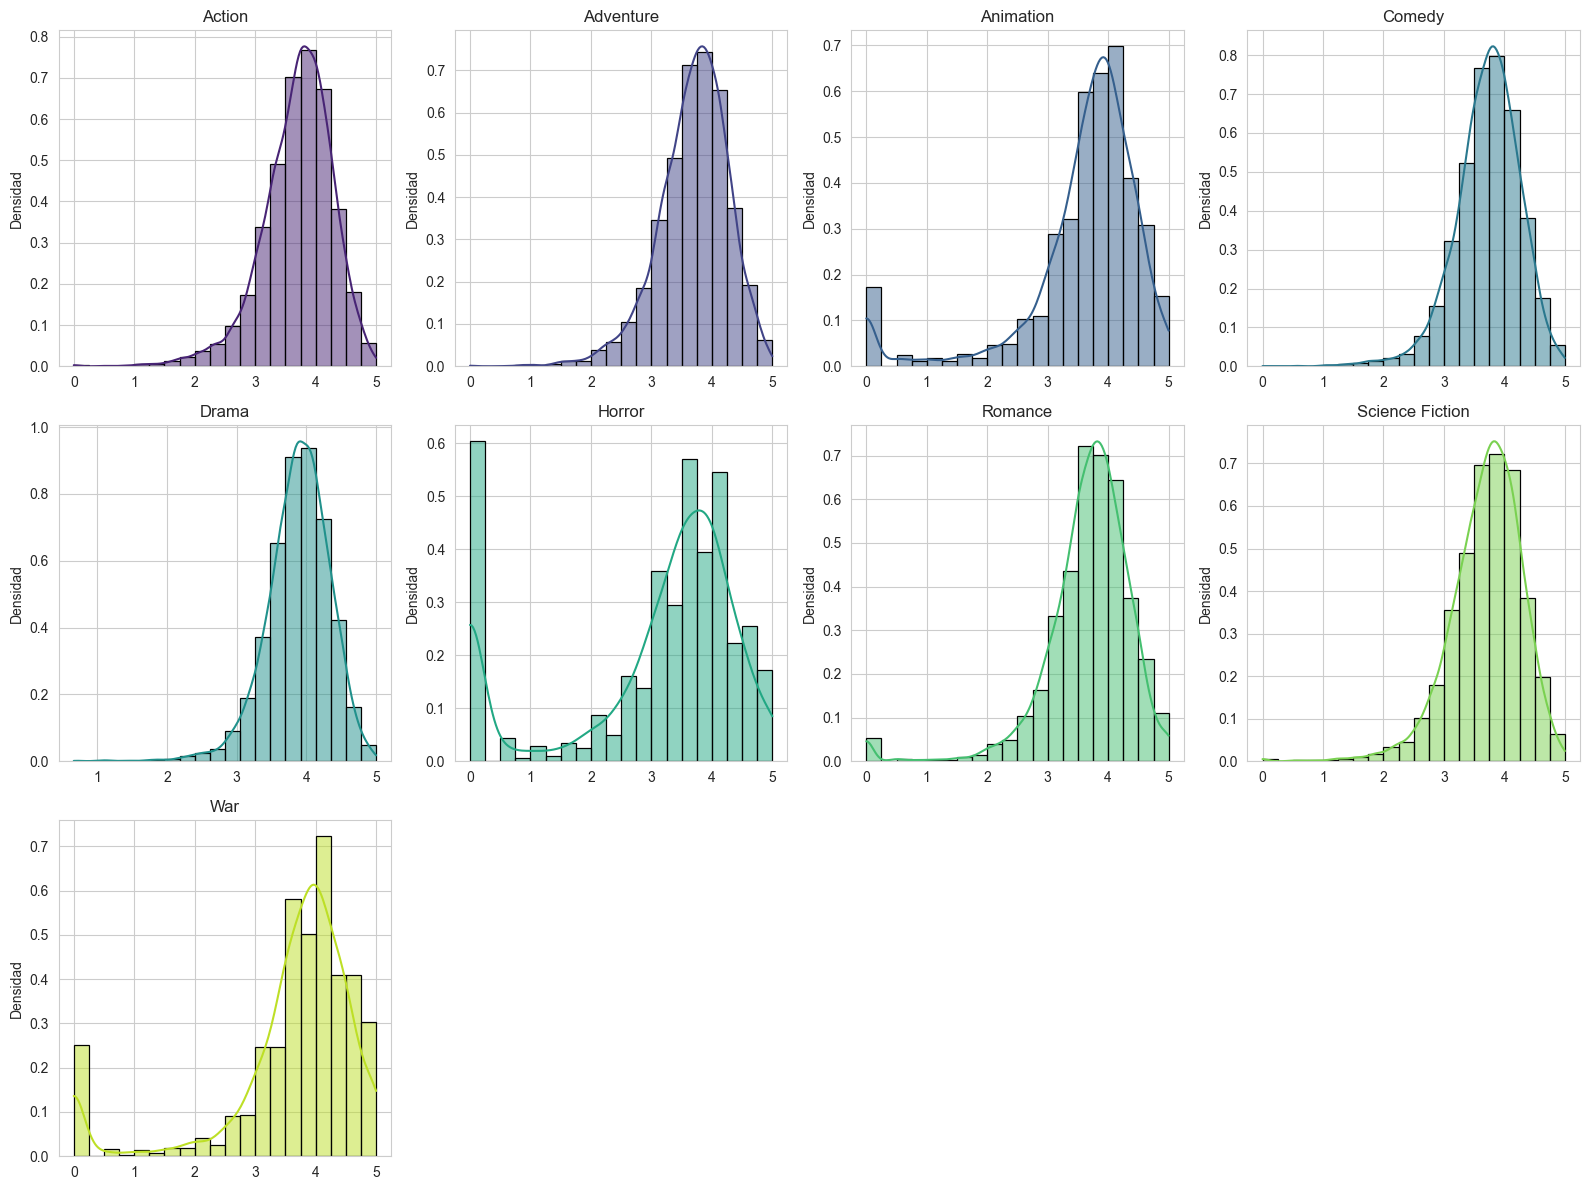

In [15]:
sns.set_style("whitegrid")
num_columns = len(df.columns)
rows = 3 
cols = 4 

# create the plot and the axis
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()
colors = sns.color_palette("viridis", num_columns)

# Plot each genre with its ratings distribution
for i, column in enumerate(df.columns):
    sns.histplot(df[column], bins=20, kde=True, ax=axes[i], color=colors[i], stat="density", edgecolor="black")
    axes[i].set_title(column, fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Densidad")

# Hide void axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Casi todos los géneros siguen una distribución normal, con medias entre 3.2 y 3.8. Esto era esperado: las calificaciones de los usuarios tienden a seguir una distribución normal (fenómeno común en sistemas de rating sociales). La guerra (`War`) es la excepción con mayor varianza, probablemente por ser un género de nicho con opiniones más polarizadas.

### Matriz de Personalidad por Género (del Paper)

In [16]:
personality = {
    "Action": [3.87, 3.45, 3.57, 3.58, 2.72],
    "Adventure": [3.91, 3.56, 3.54, 3.68, 2.61],
    "Animation": [4.04, 3.22, 3.26, 3.35, 3.02],
    "Comedy": [3.88, 3.44, 3.58, 3.60, 2.75],
    "Drama": [3.99, 3.43, 3.66, 3.60, 2.86],
    "Horror": [3.90, 3.38, 3.52, 3.47, 2.91],
    "Romance": [3.88, 3.44, 3.62, 3.62, 2.71],
    "Science Fiction": [3.99, 3.55, 3.53, 3.57, 2.73],
    "War": [3.82, 3.51, 3.49, 3.50, 2.71]
}

personality = pd.DataFrame.from_dict(personality, orient='index', columns=['Openness', 'Conscientiousness', 'Extraversion', 'Agreeableness', 'Neuroticism'])
personality.head(10)

,Openness,Conscientiousness,Extraversion,Agreeableness,Neuroticism
Action,3.87,3.45,3.57,3.58,2.72
Adventure,3.91,3.56,3.54,3.68,2.61
Animation,4.04,3.22,3.26,3.35,3.02
Comedy,3.88,3.44,3.58,3.60,2.75
Drama,3.99,3.43,3.66,3.60,2.86
Horror,3.90,3.38,3.52,3.47,2.91
Romance,3.88,3.44,3.62,3.62,2.71
Science Fiction,3.99,3.55,3.53,3.57,2.73
War,3.82,3.51,3.49,3.50,2.71


La matriz contiene los valores promedio de cada rasgo Big Five para la audiencia típica de cada género cinematográfico, según el estudio de Nave et al. (2017). Los valores de Openness son los más altos en todos los géneros (~3.8-4.1), mientras que Neuroticism tiene los valores más bajos (~2.6-3.0).

In [17]:
personality.mean()

Openness             3.920000
Conscientiousness    3.442222
Extraversion         3.530000
Agreeableness        3.552222
Neuroticism          2.780000
dtype: float64

In [18]:
personality.std()

Openness             0.071063
Conscientiousness    0.102198
Extraversion         0.113908
Agreeableness        0.098079
Neuroticism          0.125797
dtype: float64

## Obtención de la Personalidad

Para obtener la personalidad de cada usuario multiplicaremos su vector de preferencias de género por la matriz de personalidad. El proceso completo es:

1. **Normalizar** las calificaciones por género del usuario
2. **Multiplicar** por la matriz de personalidad del paper
3. **Reescalar** los resultados al rango 1-5

Exploraremos distintos métodos de normalización para encontrar el que produce la mayor diferenciación entre rasgos y entre usuarios.

In [19]:
def plot(df):
    # Plot
    axes = df.hist(bins=20, figsize=(12, 6), edgecolor='black', grid=False)

    # Optional styling tweaks
    for ax in axes.flatten():
        ax.set_title(ax.get_title(), fontsize=12)
        ax.set_xlabel(ax.get_xlabel(), fontsize=10)
        ax.set_ylabel("Frequency", fontsize=10)
        ax.tick_params(axis='both', labelsize=9)

    plt.tight_layout()
    plt.show()

### Método 1: Ratings Originales Sin Normalización

Como primera aproximación, multiplicamos directamente la matriz de calificaciones promedio por la matriz de personalidad. Luego intentamos devolver los valores a la escala original dividiendo por el promedio de calificaciones × 10 (número de géneros).

In [20]:
# Multiply the users preference by the genre personality
df_personality = df @ personality
df_personality.head()

,Openness,Conscientiousness,Extraversion,Agreeableness,Neuroticism
user_id,,,,,
31,139.370747,122.504645,125.637069,126.327990,98.952661
65,87.765591,78.095348,80.166227,80.512273,61.601530
75,121.850141,107.507901,109.833260,110.444724,86.362318
81,106.959451,94.208269,96.486795,97.110618,75.737184
110,121.319180,106.453170,109.192231,109.874017,86.059867


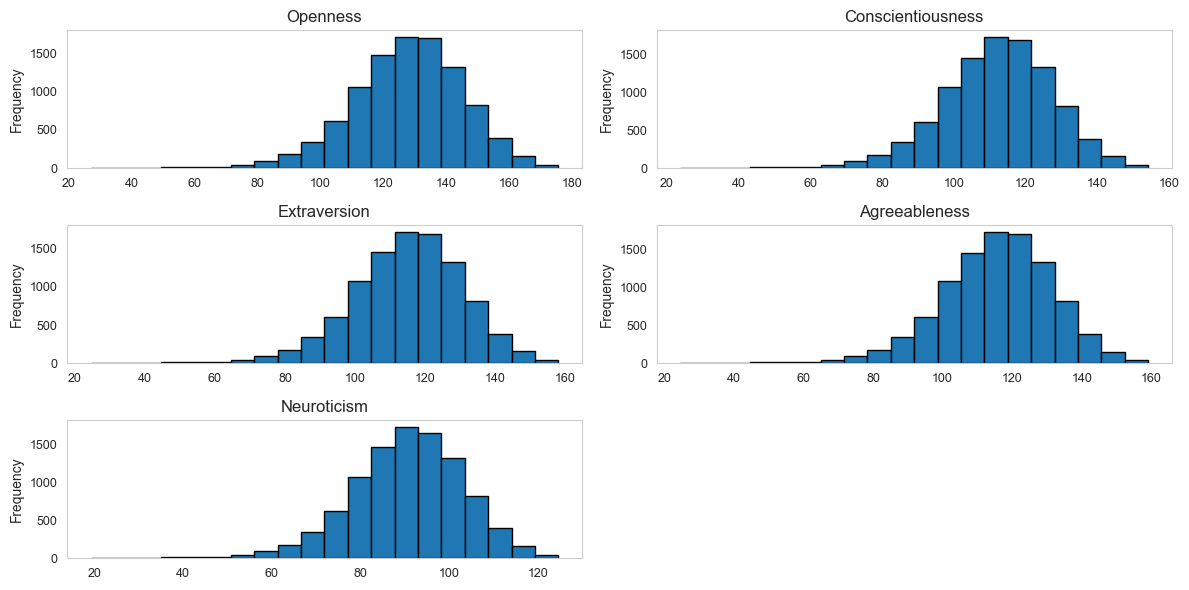

In [21]:
plot(df_personality)

Sin normalización obtenemos una distribución normal, con Openness con los valores más altos y Neuroticism los más bajos. Al intentar reescalar a 1-5, la distribución se colapsa y perdemos la normalidad.

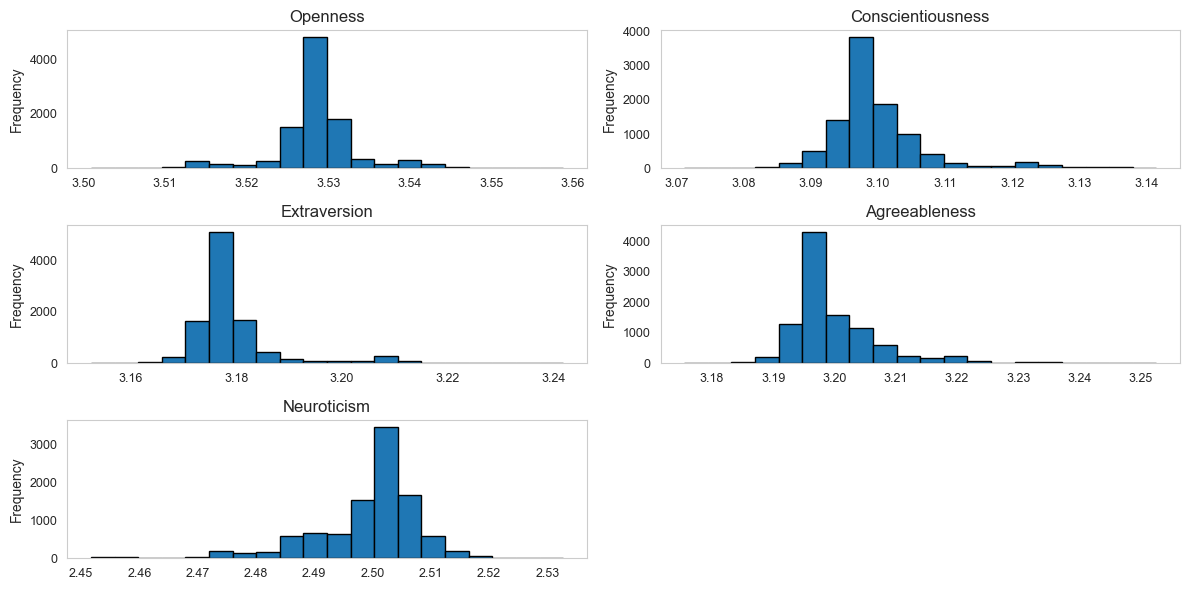

In [22]:
df_mean = df.mean(axis=1)
plot(df_personality.div(df_mean * 10, axis=0))

Al dividir por el promedio × 10 para volver a la escala 1-5, la distribución se colapsa. Este enfoque no funciona bien para la reescalación.

### Método 2: Normalización por Suma Total

Dividimos cada calificación de género por la suma total de calificaciones del usuario, manteniendo las mismas proporciones relativas entre géneros.

- **Efecto:** Las proporciones relativas se mantienen, pero todos los usuarios quedan en el mismo rango (suma = 1)
- **Limitación esperada:** Los valores del vector resultante serán muy similares entre usuarios porque la varianza de la matriz de personalidad es baja

In [23]:
# Normalize the ratings of each user
df_normalized = df.div(df.sum(axis=1), axis=0)
df_normalized.head()

genres,Action,Adventure,Animation,Comedy,Drama,Horror,Romance,Science Fiction,War
user_id,,,,,,,,,
31,0.102374,0.100578,0.104917,0.119742,0.120738,0.112411,0.100367,0.098360,0.140514
65,0.131481,0.122379,0.000000,0.111253,0.145371,0.066752,0.144629,0.133504,0.144629
75,0.146876,0.127246,0.076348,0.084958,0.136622,0.136622,0.000000,0.130595,0.160732
81,0.125783,0.126951,0.096762,0.111992,0.131196,0.091532,0.073226,0.096108,0.146451
110,0.102354,0.106102,0.117617,0.111589,0.119435,0.101007,0.116360,0.110098,0.115437


In [24]:
# Personality per user
res_normalized = df_normalized @ personality
res_normalized.head()

,Openness,Conscientiousness,Extraversion,Agreeableness,Neuroticism
user_id,,,,,
31,3.916698,3.442715,3.530745,3.550161,2.780840
65,3.905690,3.475351,3.567508,3.582907,2.741353
75,3.917047,3.455995,3.530747,3.550403,2.776240
81,3.916080,3.449224,3.532647,3.555487,2.772947
110,3.921321,3.440816,3.529349,3.551386,2.781657


Las calificaciones resultantes son prácticamente iguales para todos los usuarios. Este enfoque pierde la diferenciación individual.

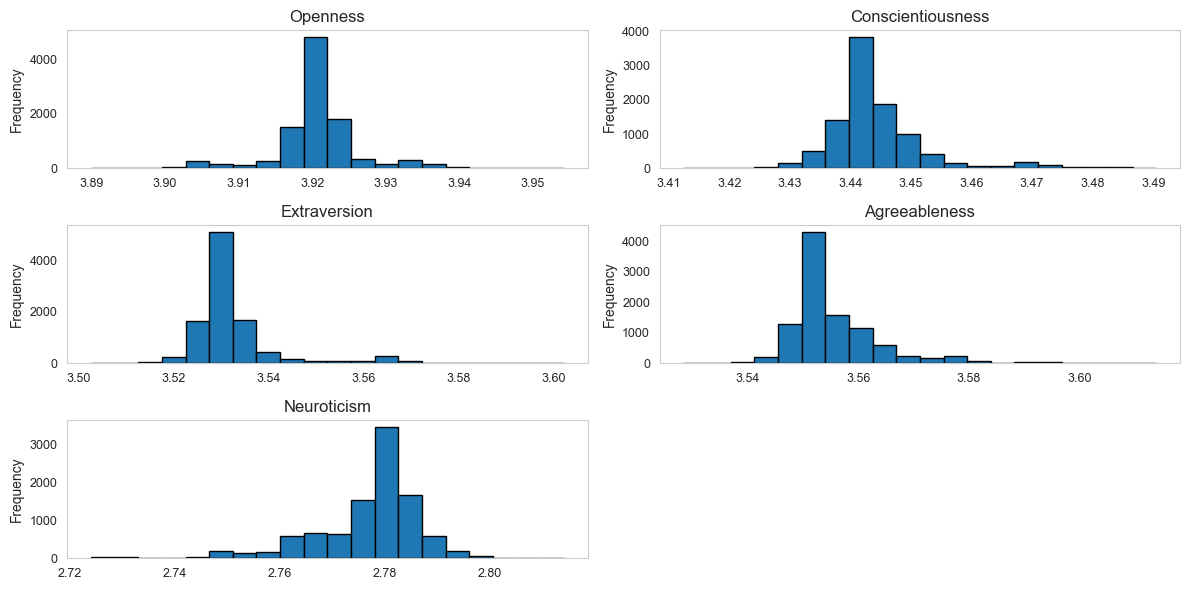

In [25]:
plot(res_normalized)

La personalidad de todos los usuarios parece ser casi idéntica, con diferencias decimales mínimas. Esto ocurre porque la matriz de personalidad tiene valores muy similares entre géneros, y la suma total normaliza demasiado las diferencias entre usuarios.

### Método 3: Normalización Min-Max

Escalamos cada fila (usuario) al rango [0, 1]: el género con menor calificación queda en 0 y el de mayor calificación queda en 1.

- **Efecto:** Amplifica las diferencias relativas entre géneros para cada usuario
- **Limitación esperada:** Al usar el rango completo [0, 1], puede crear una distribución casi uniforme al multiplicar por la matriz

In [26]:
# Normalización Min-Max por usuario
df_min_max = (df - df.min(axis=1).values.reshape(-1,1)) / (df.max(axis=1) - df.min(axis=1)).values.reshape(-1,1)
df_min_max.head()

genres,Action,Adventure,Animation,Comedy,Drama,Horror,Romance,Science Fiction,War
user_id,,,,,,,,,
31,0.095238,0.052632,0.155556,0.507246,0.530864,0.333333,0.047619,0.000000,1.000000
65,0.904453,0.841837,0.000000,0.765306,1.000000,0.459184,0.994898,0.918367,0.994898
75,0.913793,0.791667,0.475000,0.528571,0.850000,0.850000,0.000000,0.812500,1.000000
81,0.717742,0.733696,0.321429,0.529412,0.791667,0.250000,0.000000,0.312500,1.000000
110,0.073084,0.276447,0.901367,0.574230,1.000000,0.000000,0.833155,0.493316,0.783040


In [27]:
res_min_max = df_min_max @ personality
res_min_max.head()

,Openness,Conscientiousness,Extraversion,Agreeableness,Neuroticism
user_id,,,,,
31,10.593831,9.383097,9.628046,9.621993,7.588441
65,26.867018,23.906739,24.540682,24.646614,18.857611
75,24.370028,21.501580,21.966652,22.088945,17.272464
81,18.199725,16.124134,16.473398,16.585309,12.848592
110,19.415461,16.909838,17.383967,17.483571,13.808216


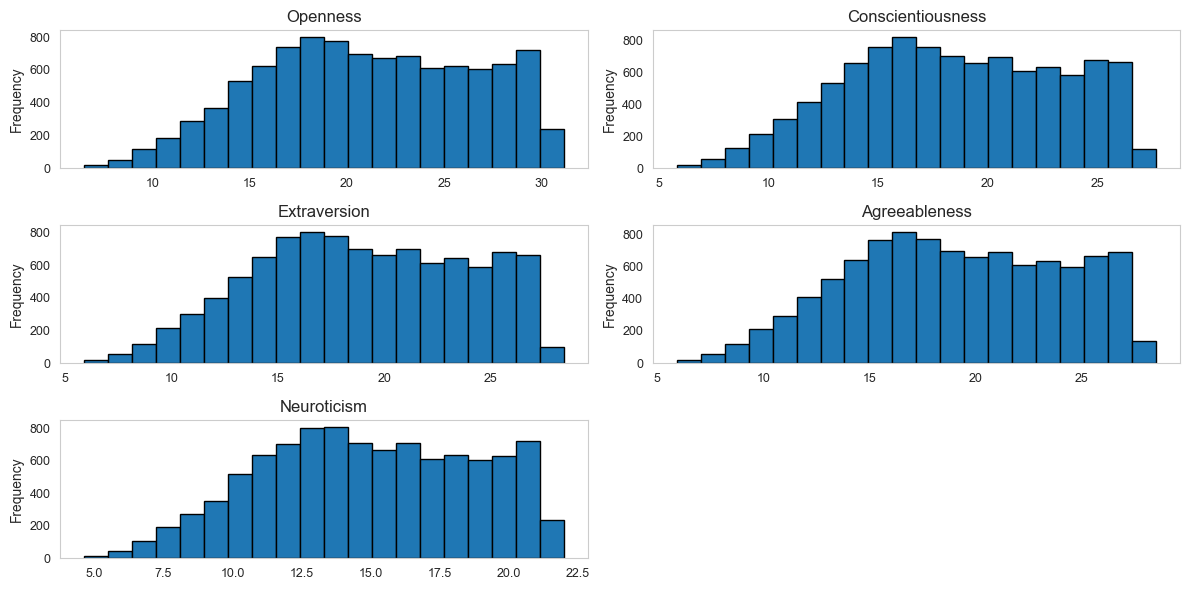

In [28]:
plot(res_min_max)

Al usar el rango completo de 0 a 1 se crea una distribución casi uniforme, que no es precisa. Necesitamos un método que preserve mejor la estructura de las preferencias.

## Método 4: Softmax

El softmax es similar a la normalización por suma total, pero con **mayor diferenciación**: los géneros con calificaciones altas reciben mucho más peso gracias a la función exponencial.

$$\sigma(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

- **Efecto:** Los géneros preferidos dominan el vector de entrada, incluso si el usuario vio pocas películas de ese género
- **Ventaja:** Mayor concentración en los géneros favoritos → mejor diferenciación de personalidad

In [29]:
def softmax_df(df):
    # Resta el máximo de cada fila para estabilidad numérica
    exp_df = np.exp(df.sub(df.max(axis=1), axis=0))
    # Divide por la suma de cada fila
    return exp_df.div(exp_df.sum(axis=1), axis=0)

In [30]:
df_softmax = softmax_df(df)
df_softmax.head()

genres,Action,Adventure,Animation,Comedy,Drama,Horror,Romance,Science Fiction,War
user_id,,,,,,,,,
31,0.071827,0.067380,0.078628,0.133255,0.138061,0.102657,0.066875,0.062265,0.279052
65,0.127622,0.104014,0.006649,0.081006,0.174372,0.029800,0.171490,0.133557,0.171490
75,0.184985,0.100448,0.020621,0.026955,0.134466,0.134466,0.001918,0.111476,0.284664
81,0.139583,0.144108,0.063183,0.095775,0.161824,0.054772,0.033221,0.062065,0.245470
110,0.083162,0.093385,0.133354,0.110664,0.141068,0.079768,0.128268,0.105675,0.124655


In [31]:
res = df_softmax @ personality
res.head()

,Openness,Conscientiousness,Extraversion,Agreeableness,Neuroticism
user_id,,,,,
31,3.901230,3.450348,3.530758,3.542516,2.776171
65,3.907087,3.475459,3.569345,3.582506,2.740963
75,3.897126,3.472143,3.539106,3.549928,2.758568
81,3.904032,3.463894,3.538414,3.560076,2.756872
110,3.924564,3.436853,3.527887,3.549029,2.786487


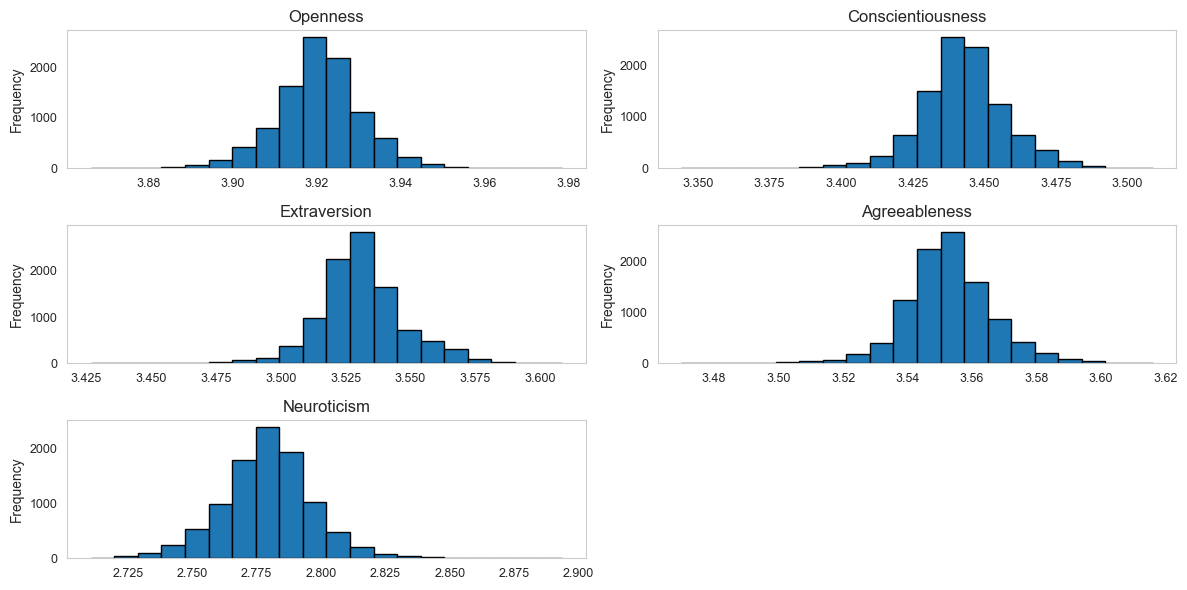

In [32]:
plot(res)

El resultado es muy similar al método de normalización por suma total, ya que la varianza de la matriz de personalidad sigue siendo baja. Sin embargo, la distribución tiene forma más normal que los métodos anteriores. Reescalando a 1-5 con Min-Max obtenemos una distribución razonable.

In [33]:
scaler = MinMaxScaler(feature_range=(1, 5))
scaled = scaler.fit_transform(res)
scaled = pd.DataFrame(scaled, columns=['OPE', 'CON', 'EXT', 'AGR', 'NEU'])
scaled.head()

,OPE,CON,EXT,AGR,NEU
0,2.245166,3.578360,3.289931,2.988839,2.434824
1,2.454348,4.188087,4.140888,4.083050,1.665062
2,2.098620,4.107581,3.474028,3.191652,2.049966
3,2.345237,3.907276,3.458774,3.469330,2.012875
4,3.078520,3.250674,3.226615,3.167047,2.660361


El reescalado de 1 a 5 con Min-Max no distorsiona tanto los valores como en los métodos anteriores. Esto se debe a que, aunque todas las distribuciones son normales, tienen medias y desviaciones estándar distintas, generando mayor diferenciación.

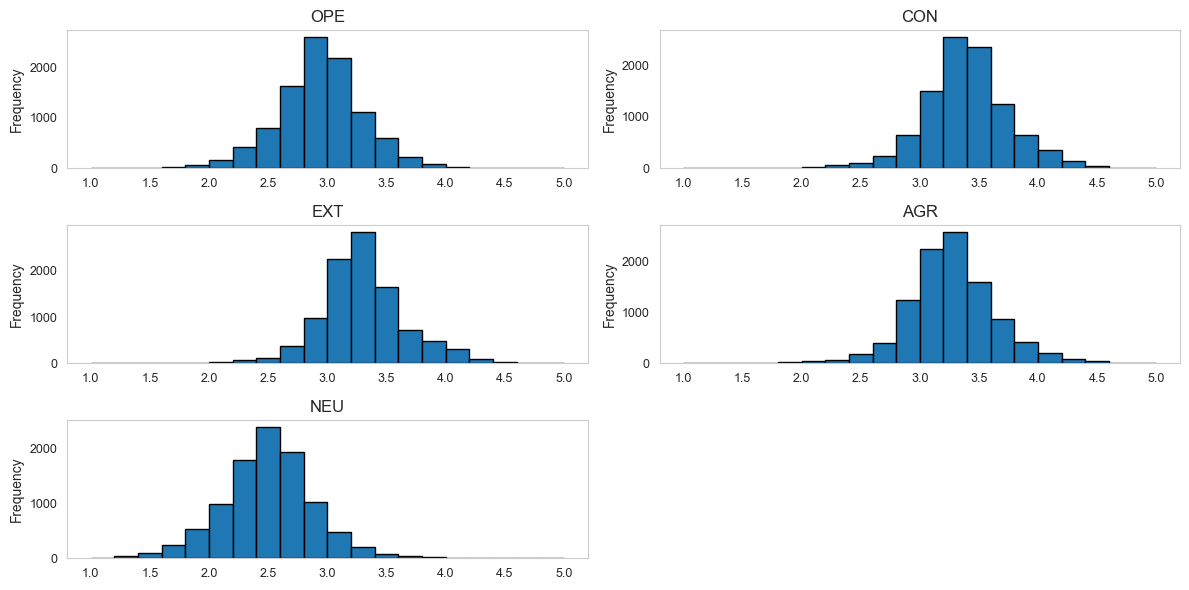

In [34]:
plot(scaled)

### Método 5: Géneros Ponderados

Multiplicamos la calificación promedio por género por la **proporción de películas vistas** en ese género. Así damos más peso a los géneros que el usuario consume habitualmente.

- **Efecto:** Combina preferencia (calificación) con hábito de consumo (proporción de vistas)
- **Desventaja:** Penaliza géneros de nicho con muchas calificaciones altas pero pocas películas vistas

In [35]:
weighted_ratings = df * genre_proportions
weighted_ratings.head()

genres,Action,Adventure,Animation,Comedy,Drama,Horror,Romance,Science Fiction,War
user_id,,,,,,,,,
31,0.421488,0.561983,0.462810,0.809917,0.958678,0.132231,0.206612,0.318182,0.041322
65,0.492424,0.166667,0.000000,0.151515,1.484848,0.022727,0.393939,0.090909,0.295455
75,1.226852,0.879630,0.175926,0.171296,0.629630,0.157407,0.000000,0.601852,0.185185
81,0.714765,1.070470,0.248322,0.348993,0.288591,0.184564,0.013423,0.281879,0.026846
110,0.426282,0.483974,0.419872,0.464744,0.971154,0.080128,0.115385,0.349359,0.160256


In [36]:
personality_scores = weighted_ratings @ personality
personality_scores.head(10)

,Openness,Conscientiousness,Extraversion,Agreeableness,Neuroticism
user_id,,,,,
31,15.410620,13.451694,13.891942,13.981694,10.905331
65,12.178258,10.698182,11.183030,11.130682,8.620303
75,15.797546,13.998102,14.309861,14.444815,11.038935
81,12.459597,11.031711,11.243322,11.414664,8.688859
110,13.682756,11.945865,12.314359,12.386763,9.680128
114,16.871250,14.871290,15.323730,15.425222,11.854093
126,15.887857,13.916679,14.179893,14.416143,11.153143
137,12.259136,10.606481,10.901235,11.042500,8.699753
144,15.124554,13.336559,13.732871,13.777748,10.636040


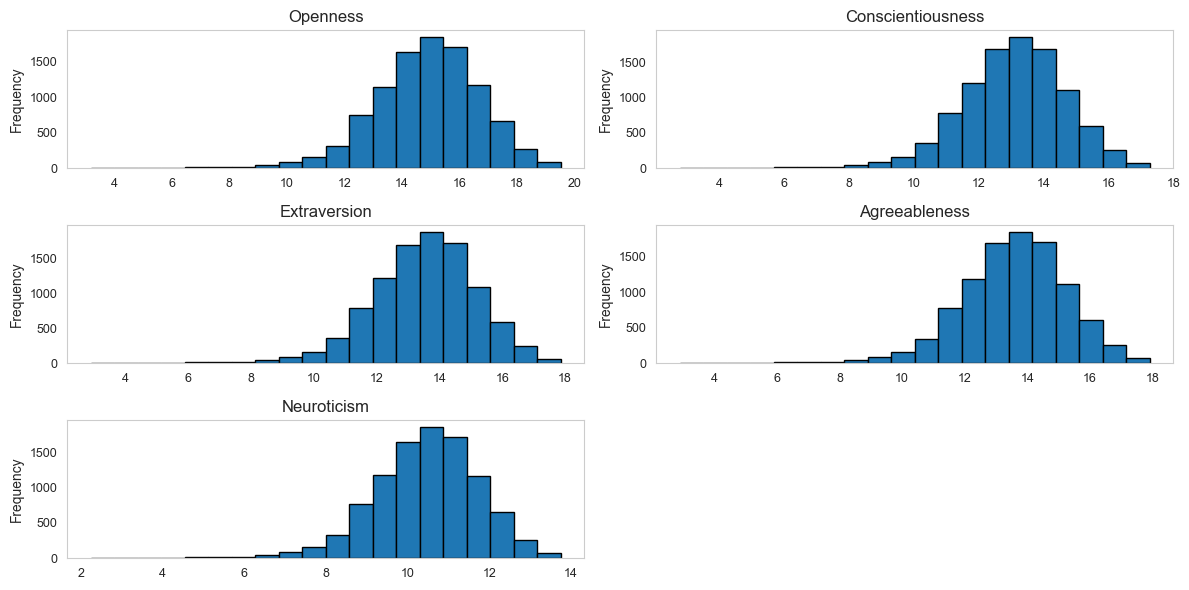

In [37]:
plot(personality_scores)

Este método parece prometedor, pero tiene un problema: da demasiado peso a los géneros más vistos independientemente de la calificación. Además, las calificaciones no están estandarizadas. Probaremos una combinación de softmax y géneros ponderados.

### Método Final: Softmax Puro

Tras probar múltiples enfoques (raw, suma total, min-max, géneros ponderados y combinaciones), la **normalización softmax pura** produce la mejor diferenciación entre rasgos de personalidad. El softmax preserva las diferencias relativas en las preferencias de género y asegura que el vector de entrada sume 1, lo que al multiplicar por la matriz de personalidad genera la mayor varianza entre usuarios.

**Nota sobre correlaciones:** La matriz del paper tiene valores similares entre géneros, lo que implica que los rasgos derivados tendrán correlaciones moderadamente altas (~0.6-0.9). Esta es una **limitación inherente al método** cuando se usan preferencias de género como proxy de personalidad. Para contrastar, el Notebook de evaluación comparará estos resultados con los del **dataset Survey**, donde los usuarios completaron un cuestionario IPIP-30 real.

In [38]:
# FINAL METHOD: Pure softmax normalization
# Softmax produces the best trait differentiation with the paper's matrix
res = df_softmax @ personality

# No outlier removal needed: Z-score rescaling + clip(1,5) in the next step
# handles extreme values without discarding users
res.head(10)

,Openness,Conscientiousness,Extraversion,Agreeableness,Neuroticism
user_id,,,,,
31,3.901230,3.450348,3.530758,3.542516,2.776171
65,3.907087,3.475459,3.569345,3.582506,2.740963
75,3.897126,3.472143,3.539106,3.549928,2.758568
81,3.904032,3.463894,3.538414,3.560076,2.756872
110,3.924564,3.436853,3.527887,3.549029,2.786487
114,3.922487,3.440984,3.524457,3.549499,2.782828
126,3.913639,3.453601,3.518593,3.547288,2.769583
137,3.946382,3.409773,3.506810,3.542778,2.806459
144,3.918821,3.434515,3.525921,3.543735,2.791113


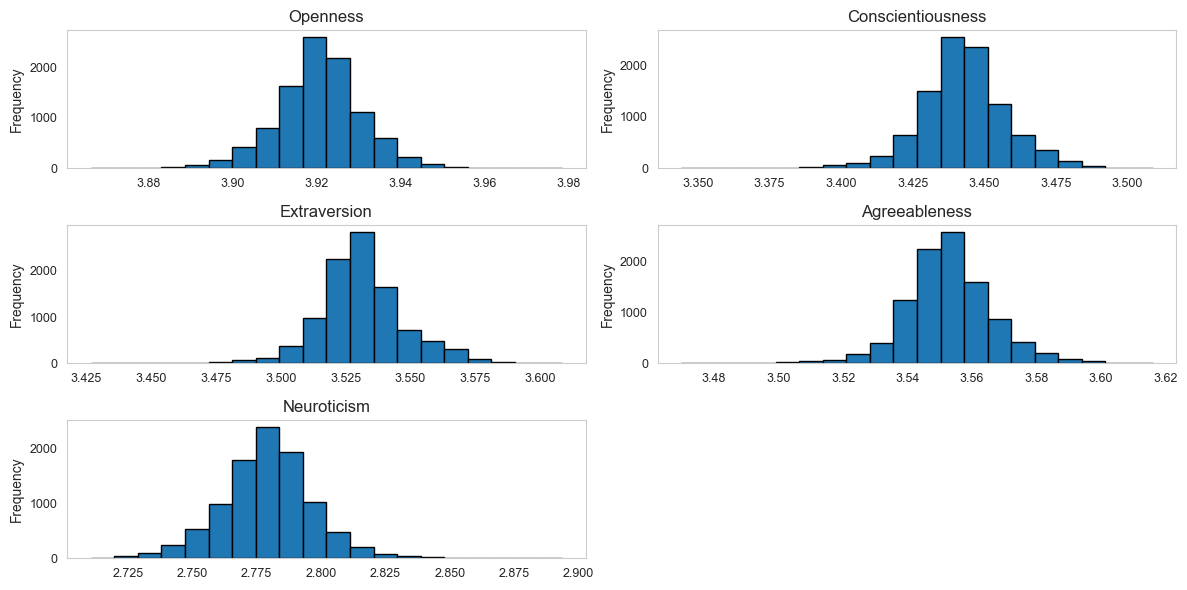

In [39]:
plot(res)

In [40]:
res.std()

Openness             0.010207
Conscientiousness    0.015042
Extraversion         0.016568
Agreeableness        0.013554
Neuroticism          0.018062
dtype: float64

Reescalamos los scores al rango 1-5 usando **estandarización Z-score por rasgo**, centrando cada rasgo en 3.0 con desviación estándar de 0.7, y recortando al rango [1, 5].

Este método garantiza:
- Misma escala (1-5) para todos los rasgos
- Sin pérdida de usuarios (el clip maneja los extremos sin descartar filas)
- Distribución normal centrada en 3.0

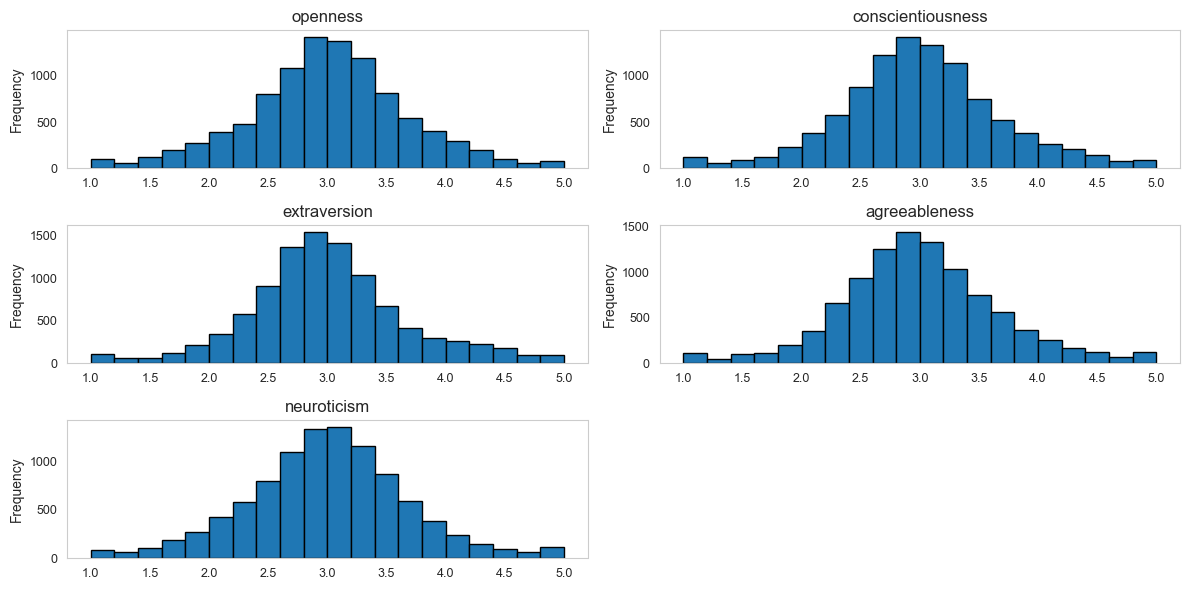

In [41]:
z_scores = pd.DataFrame(index=res.index)

for column in res.columns:
    z = (res[column] - res[column].mean()) / res[column].std()
    z_scores[column] = 3.0 + 0.7 * z

# Clip to [1, 5] range
z_scores = z_scores.clip(1, 5)

# Rename columns to lowercase
z_scores.columns = ['openness', 'conscientiousness', 'extraversion', 'agreeableness', 'neuroticism']

plot(z_scores)

In [42]:
z_scores.head(10)

,openness,conscientiousness,extraversion,agreeableness,neuroticism
user_id,,,,,
31,1.662300,3.349319,2.989807,2.462928,2.875244
65,2.064018,4.517869,4.620067,4.528310,1.510733
75,1.380869,4.363578,3.342500,2.845748,2.193028
81,1.854480,3.979690,3.313276,3.369882,2.127281
110,3.262698,2.721305,2.868507,2.799304,3.275041
114,3.120232,2.913538,2.723607,2.823587,3.133242
126,2.513397,3.500665,2.475866,2.709426,2.619903
137,4.759025,1.461101,1.978006,2.476488,4.049070
144,2.868809,2.612474,2.785468,2.525909,3.454322


## Conclusiones

El mejor enfoque para extraer perfiles de personalidad a partir de preferencias de género es la **normalización softmax** seguida de la multiplicación con la matriz del paper y el reescalado Z-score a 1-5.

**Hallazgos clave:**
- Softmax proporciona la mejor diferenciación de rasgos frente a los métodos raw, suma-normalizado, min-max y ponderado
- Los 10,000 usuarios tienen cobertura completa de personalidad
- Todos los rasgos están en la escala 1-5
- Las correlaciones entre rasgos son moderadamente altas (~0.6-0.9) debido a la homogeneidad de la matriz del paper — limitación documentada y aceptada

**Limitación:** La personalidad derivada de géneros cinematográficos es una aproximación. Los modelos evaluados con este método se contrastarán con modelos evaluados usando el **dataset Survey** (cuestionario IPIP-30 real) para cuantificar la diferencia.

### Guardado de los Rasgos de Personalidad

Guardamos el archivo con 2 decimales para reducir el tamaño y mantener precisión suficiente.

In [43]:
for column in z_scores.columns:
    z_scores[column] = z_scores[column].round(2)

print(f'Final personality data: {z_scores.shape[0]:,} users, traits in [{z_scores.min().min():.2f}, {z_scores.max().max():.2f}]')
z_scores.head()

Final personality data: 10,000 users, traits in [1.00, 5.00]


,openness,conscientiousness,extraversion,agreeableness,neuroticism
user_id,,,,,
31,1.66,3.35,2.99,2.46,2.88
65,2.06,4.52,4.62,4.53,1.51
75,1.38,4.36,3.34,2.85,2.19
81,1.85,3.98,3.31,3.37,2.13
110,3.26,2.72,2.87,2.80,3.28


In [44]:
z_scores.index.name = 'user_id'
z_scores.to_csv('../data/processed/personality.csv')

# Verify: correlation between traits
print('Trait correlations:')
print(z_scores.corr().round(3))

Trait correlations:
                   openness  conscientiousness  extraversion  agreeableness  \
openness              1.000             -0.672        -0.530         -0.298   
conscientiousness    -0.672              1.000         0.686          0.753   
extraversion         -0.530              0.686         1.000          0.837   
agreeableness        -0.298              0.753         0.837          1.000   
neuroticism           0.593             -0.937        -0.625         -0.823   

                   neuroticism  
openness                 0.593  
conscientiousness       -0.937  
extraversion            -0.625  
agreeableness           -0.823  
neuroticism              1.000  


## Resumen del Notebook

En este notebook se extrajeron los rasgos de personalidad Big Five para todos los usuarios del dataset de MovieLens a partir de sus preferencias de géneros cinematográficos.

**Metodología final:**
1. Calcular la calificación promedio por género para cada usuario
2. Aplicar normalización **softmax** para convertir las preferencias en una distribución
3. Multiplicar por la **matriz de personalidad por género** (Nave et al., 2017)
4. Reescalar con **Z-score por rasgo** centrado en 3.0 (std=0.7), recortado a [1, 5]

**Resultado:** Perfiles Big Five para **10,000 usuarios**, todos los rasgos en escala 1-5

**Limitación documentada:** Correlaciones entre rasgos ~0.6-0.9 (inherente a la matriz del paper)

**Output generado:** `ml/data/processed/personality.csv`